In [30]:
import os
import os.path as op
import pandas as pd
import numpy as np
import nibabel as nib
from scipy.stats import normaltest, ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

datapool_root_folder = '/mnt_AdaBD_largefiles/Data/DNumRisk_Data'#. #'/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk'
dataset = 'smile' #'numberline'  #
bids_folder = op.join(datapool_root_folder, f'ds-{dataset}')
subList = [int(d[4:]) for d in os.listdir(bids_folder) if d.startswith('sub-')]

group_mapping = pd.DataFrame({'group':[int(d[4]) for d in os.listdir(bids_folder) if d.startswith('sub-')]},index=subList)
group_mapping['group'] = group_mapping['group'].map({1:'DD',2:'DD',3:'control'}) # works for both datasets


In [3]:
from utils import get_gradients_tasks
tasks =['rest', 'magjudge', 'placevalue']
df_gms_tasks  = get_gradients_tasks(subList, bids_folder=bids_folder, tasks = tasks)

df_gm_std_tasks = pd.DataFrame(df_gms_tasks.std(axis=1), columns=['std'])


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


File not found: /mnt_AdaBD_largefiles/Data/DNumRisk_Data/ds-smile/derivatives/gradients/sub-207/sub-207_ses-1-2_task-placevalue_g-aligned.npy


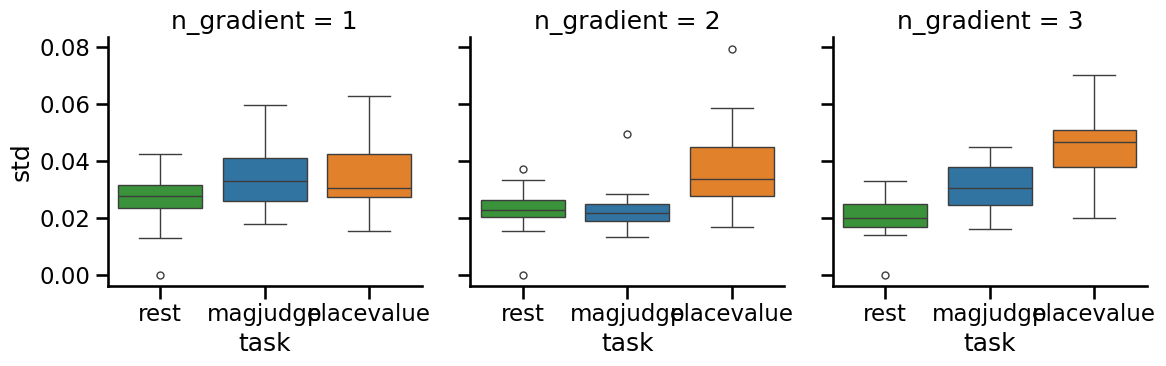

In [15]:
task_order = ['rest', 'magjudge', 'placevalue']

df = df_gm_std_tasks.reset_index().copy()
df['task'] = pd.Categorical(df['task'], categories=task_order, ordered=True)

sns.catplot(data=df,
    x='task',         
    y='std',
    hue='task',
    col='n_gradient',
    kind='box',
    order=task_order, 
    hue_order = ['magjudge', 'placevalue', 'rest'],
    height=4,
    aspect=1
)


In [20]:
df_gm_std_tasks.groupby(['n_gradient','task']).mean()

std
n_gradient task                
1          magjudge    0.034785
           placevalue  0.035213
           rest        0.027557
2          magjudge    0.022014
           placevalue  0.036450
           rest        0.023235
3          magjudge    0.030963
           placevalue  0.044174
           rest        0.020807

In [31]:
(df_gm_std_tasks.xs(('magjudge',1), level=('task','n_gradient')).values.flatten()).shape

(43,)

In [41]:
## Reliabilit of std?
import pingouin as pg

from itertools import combinations
tmp = df_gm_std_tasks.drop(207,level='subject')
for task1, task2 in combinations(tasks, 2):
        print(f"{task1} - {task2}")
        for n_grad in [1,2,3]:
                corr = pg.corr(tmp.xs((task1,n_grad), level=('task','n_gradient')).values.flatten(),
                        tmp.xs((task2,n_grad), level=('task','n_gradient')).values.flatten())
                print(f'n_grad={n_grad}, corr={corr["r"].values[0]:.3f}, pval={corr["p-val"].values[0]:.3f}') 
        print('---')

rest - magjudge
n_grad=1, corr=0.301, pval=0.052
n_grad=2, corr=0.180, pval=0.253
n_grad=3, corr=0.221, pval=0.159
---
rest - placevalue
n_grad=1, corr=0.252, pval=0.107
n_grad=2, corr=0.349, pval=0.024
n_grad=3, corr=0.272, pval=0.082
---
magjudge - placevalue
n_grad=1, corr=0.505, pval=0.001
n_grad=2, corr=0.092, pval=0.560
n_grad=3, corr=0.202, pval=0.200
---


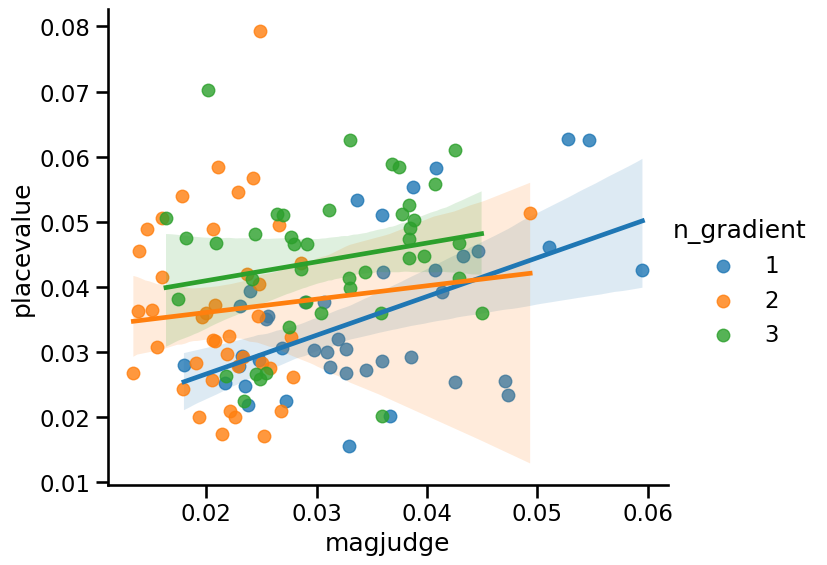

In [45]:
tmp = df_gm_std_tasks.unstack('task').droplevel(0, axis=1)
sns.lmplot(data=tmp.reset_index(), x='magjudge', y='placevalue', hue='n_gradient', height=6, aspect=1.2)

## Group differences

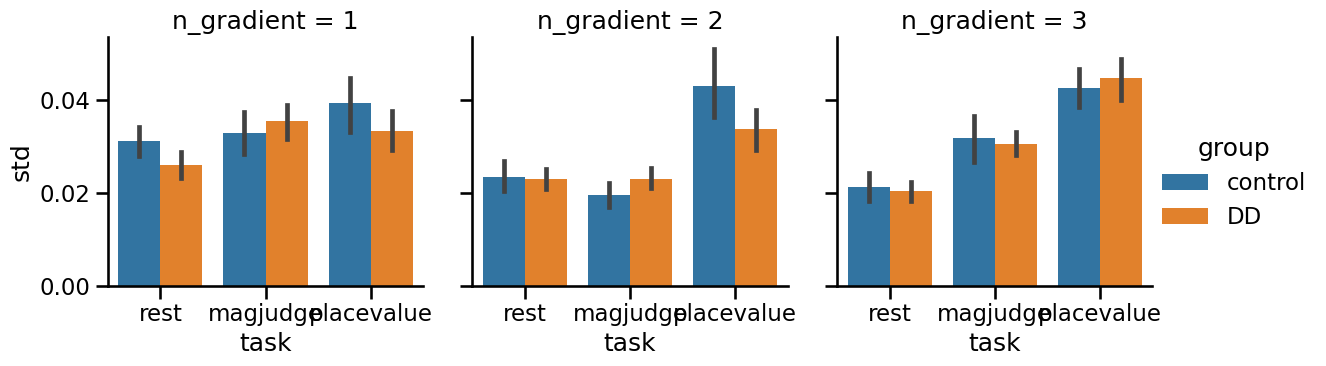

In [ ]:
tmp = df.set_index('subject').join(group_mapping, on='subject')

sns.catplot(data=tmp, col='n_gradient', y='std', x='task', hue='group', hue_order = ['control','DD'],
            kind='bar', height=4, aspect=1)

## Eccentricity changes by task?

In [ ]:
df_gms_tasks  = get_gradients_tasks(subList, bids_folder=bids_folder, tasks = tasks, derivative_obj_name='gradients')


In [15]:
from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping, get_basic_mask
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(glasser_CAatlas_mapping['ca_network'].values , labeling_glasser, mask=mask_glasser) #, fill=np.nan) #grad_sub[n_grad-1]

mask, _ = get_basic_mask()
caNets_fsav5_mapping = caNets_fsav5_mapping[mask]

In [56]:
nets_of_interest = [2, 3, 5, 9]  # visual, somato-motor, default

df_eccentricities = []

for n_network in nets_of_interest:
    net_mask = np.where(caNets_fsav5_mapping == (n_network))[0]
    df_onlyNet = df_gms_tasks[net_mask]
    eccentricities = np.sqrt(df_onlyNet.xs(1,0,'n_gradient')**2 + df_onlyNet.xs(2,0,'n_gradient')**2 + df_onlyNet.xs(3,0,'n_gradient')**2)
    eccentricities = pd.DataFrame(eccentricities.mean(axis=1), columns=['mean_ecc'])
    eccentricities['net'] = CAatlas_names.loc[n_network]['Network Name']
    df_eccentricities.append(eccentricities) #, column=['mean_ecc']))
 
df_eccentricities = pd.concat(df_eccentricities, axis=0)


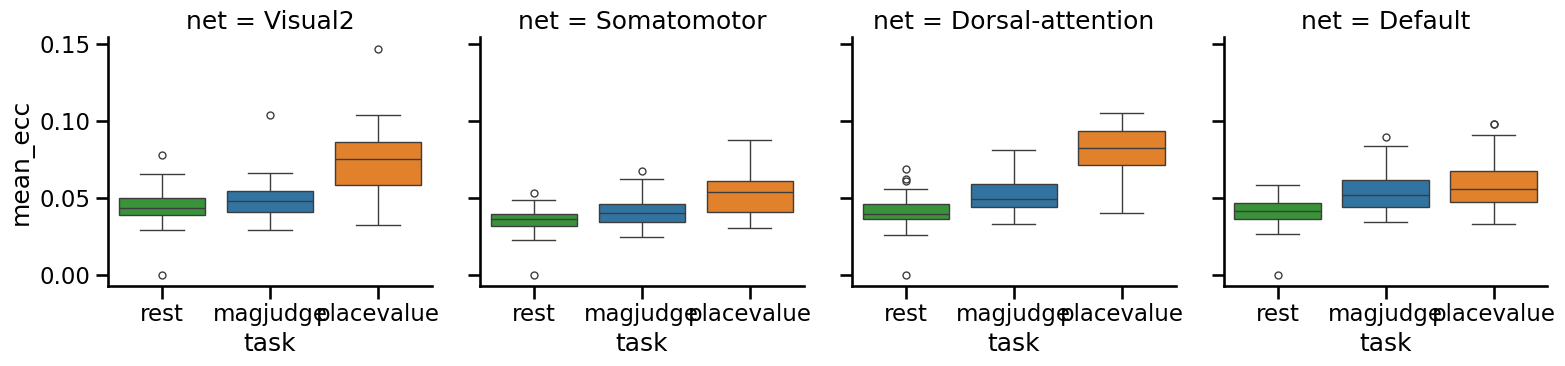

In [57]:
task_order = ['rest', 'magjudge', 'placevalue']

df = df_eccentricities.reset_index().copy()
df['task'] = pd.Categorical(df['task'], categories=task_order, ordered=True)

sns.catplot(data=df,
    x='task',         
    y='mean_ecc',
    hue='task',
    col='net',
    kind='box',
    order=task_order, 
    hue_order = ['magjudge', 'placevalue', 'rest'],
    height=4,
    aspect=1
)
